# Predict stock value with GRU layer Chapter 15 Workshop 6

## Load module

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout, LSTM

import os

## Set paramter

In [42]:
dataset_path = '../datasets/IBM_2006-01-01_to_2018-01-01.csv'

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path, index_col='Date')
    df.index = pd.to_datetime(df.index)
else:
    raise FileNotFoundError(f"Dataset not found at {dataset_path}. Please provide the correct path.")

In [44]:
test_np = df.values
print(test_np.shape)
print(test_np[:5])

(3020, 6)
[[82.45 82.55 80.81 82.06 11715200 'IBM']
 [82.2 82.5 81.33 81.95 9840600 'IBM']
 [81.4 82.9 81.0 82.5 7213500 'IBM']
 [83.95 85.03 83.41 84.95 8197400 'IBM']
 [84.1 84.25 83.38 83.73 6858200 'IBM']]


In [45]:
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


## Prepare data

In [46]:
print('Check null')
print(df.isnull().sum())
print('-----------------------------------')
print('Check number of rows')
print(df.count())

Check null
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64
-----------------------------------
Check number of rows
Open      3019
High      3020
Low       3019
Close     3020
Volume    3020
Name      3020
dtype: int64


In [47]:
if df.isnull().values.any():
    df = df.dropna()
print(df.isnull().sum())
print('-----------------------------------')
print('Check number of rows')
print(df.count())

Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64
-----------------------------------
Check number of rows
Open      3019
High      3019
Low       3019
Close     3019
Volume    3019
Name      3019
dtype: int64


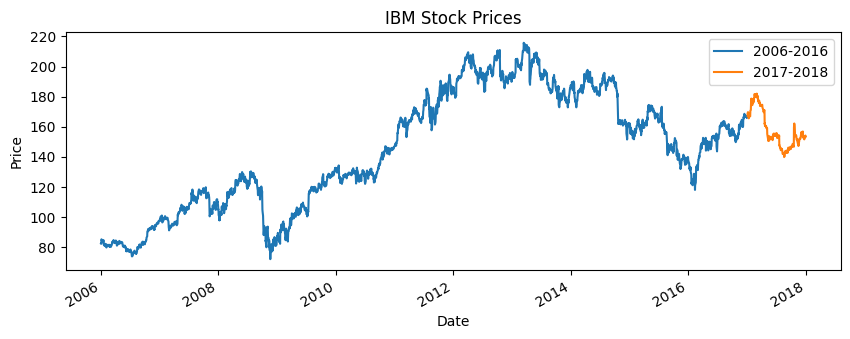

In [48]:
df = df.Close
df.head()


df[:'2016'].plot(figsize=(10, 3.5), legend=True)
df['2017':].plot(figsize=(10, 3.5), legend=True)
plt.legend(['2006-2016', '2017-2018'])
plt.title('IBM Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [49]:
print('Samplees:', df.shape)
print('Train set:', df[:'2016'].shape)
print(df.head())

Samplees: (3019,)
Train set: (2769,)
Date
2006-01-03    82.06
2006-01-04    81.95
2006-01-05    82.50
2006-01-06    84.95
2006-01-09    83.73
Name: Close, dtype: float64


## Nomalization

In [50]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
data = df.values.reshape(-1, 1)     # numpy array
data_sc = sc.fit_transform(data)
data_sc[:5]


array([[0.07163682],
       [0.07087325],
       [0.0746911 ],
       [0.0916979 ],
       [0.08322921]])

### Convert Function

In [72]:
def convertToMatrix(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step),])
        y.append(data[i + time_step,])
    return np.array(X), np.array(y)

In [73]:
step = 60
n_train = df[:'2016'].shape[0]
X_train, y_train = convertToMatrix(data_sc[:n_train], time_step=step)
X_test, y_test = convertToMatrix(data_sc[n_train:], time_step=step)

In [74]:
print(data_sc[:n_train].shape, data_sc[n_train:].shape)
print(f'Train shqape: {X_train.shape}, {y_train.shape}')
print(f'Test shqape: {X_test.shape}, {y_test.shape}')

(2769, 1) (250, 1)
Train shqape: (2708, 60, 1), (2708, 1)
Test shqape: (189, 60, 1), (189, 1)


## Create model

In [76]:
model = Sequential()
# GRU is 2 bias and 3 gates (update, reset, output)
# Parameters = 3 × [features + Units + 2] x Units
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1] , X_train.shape[2]), activation='relu'))
model.add(Dropout(0.2))
model.add(GRU(units=40, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='rmsprop', loss='mean_squared_error')
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None, 60, 50)            7950      
                                                                 
 dropout_2 (Dropout)         (None, 60, 50)            0         
                                                                 
 gru_3 (GRU)                 (None, 40)                11040     
                                                                 
 dropout_3 (Dropout)         (None, 40)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 41        
                                                                 
Total params: 19,031
Trainable params: 19,031
Non-trainable params: 0
_________________________________________________________________


## Train model

In [77]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
85/85 [==============================] - 17s 177ms/step - loss: 0.0400
Epoch 2/50
85/85 [==============================] - 17s 202ms/step - loss: 0.0077
Epoch 3/50
85/85 [==============================] - 15s 176ms/step - loss: 0.0063
Epoch 4/50
85/85 [==============================] - 15s 181ms/step - loss: 0.0058
Epoch 5/50
85/85 [==============================] - 15s 175ms/step - loss: 0.0054
Epoch 6/50
85/85 [==============================] - 15s 176ms/step - loss: 0.0046
Epoch 7/50
85/85 [==============================] - 15s 171ms/step - loss: 0.0044
Epoch 8/50
85/85 [==============================] - 15s 172ms/step - loss: 0.0041
Epoch 9/50
85/85 [==============================] - 14s 170ms/step - loss: 0.0038
Epoch 10/50
85/85 [==============================] - 15s 178ms/step - loss: 0.0035
Epoch 11/50
85/85 [==============================] - 15s 171ms/step - loss: 0.0035
Epoch 12/50
85/85 [==============================] - 14s 170ms/step - loss: 0.0032
Epoch 13/50
8

## Ploting loss curve

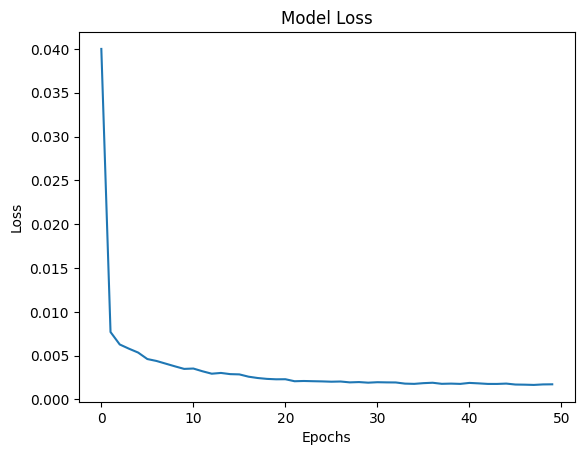

In [78]:
loss = history.history['loss']
plt.plot(loss)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.show()

## Evaluate model

In [79]:
testPredict = model.predict(X_test)

6/6 [==============================] - 0s 41ms/step


In [87]:
testPredict_inv = sc.inverse_transform(testPredict)
y_test_inv = sc.inverse_transform(y_test)

from sklearn.metrics import mean_squared_error, r2_score
mse_test = np.sqrt(mean_squared_error(y_test_inv, testPredict_inv))
r2_test = r2_score(y_test_inv, testPredict_inv)

print(f'MSE: {mse_test:.4f}')
print(f'R2: {r2_test:.4f}')

MSE: 3.5135
R2: 0.7781


## Visulizae test dataset

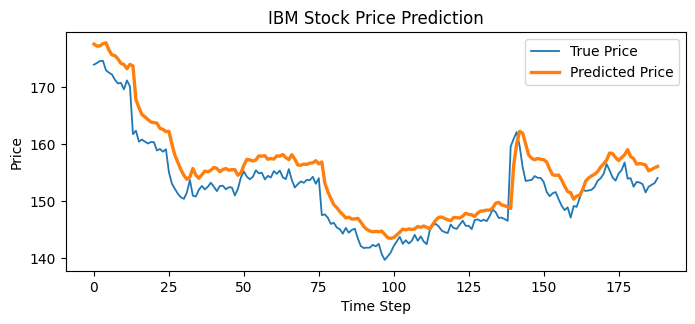

In [88]:
plt.figure(figsize=(8, 3.1))
plt.plot(y_test_inv, lw=1.3,label='True Price')
plt.plot(testPredict_inv, lw=2.4, label='Predicted Price')
plt.title('IBM Stock Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.show()

## Save model

In [89]:
model_path = '../models/ibm_stock_prediction.h5'
if not os.path.exists(os.path.dirname(model_path)):
    print('directory does not exist')
else:
    # model.save(model_path)
    print(f'Model saved to {model_path}')

Model saved to ../models/ibm_stock_prediction.h5


# Note

Change	Effect
Increase X_train.shape[1]	Longer sequences, more temporal context, but more computation + overfitting risk
Switch GRU → LSTM	        More expressive model, better for long dependencies, but more compute-heavy